In [1]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import torch
import matplotlib.pyplot as plt
import os
import numpy as np

model_name = "CIDAS/clipseg-rd64-refined"
processor = CLIPSegProcessor.from_pretrained(model_name)
model = CLIPSegForImageSegmentation.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model loaded on {device}")

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on cpu


In [5]:
image_dir = "images"
images_and_prompts = {
    "bird.jpg": ["bird", "branch"],
    "cats_dog.png": ["cat", "dog", "bed"],
    "kitchen.png": ["sink", "stove", "cabinet", "countertop"],
    "pizza.png": ["pizza slices", "pepperoni"]
}

def segment_image(image_path, prompts):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(text=prompts, images=[image] * len(prompts), padding="max_length", return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)

    preds = torch.sigmoid(outputs.logits)

    return image, preds

def plot_results(image, preds, prompts):
    n = len(prompts)
    fig, ax = plt.subplots(1, n + 1, figsize=((n + 1) * 4, 4))

    ax[0].imshow(image)
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    for i, prompt in enumerate(prompts):
        mask = preds[i].cpu().numpy()

        ax[i + 1].imshow(image)
        ax[i + 1].imshow(mask, alpha=0.6, cmap="jet")
        ax[i + 1].set_title(f"Prompt: {prompt}")
        ax[i + 1].axis("off")
    
    plt.show()

Processing bird.jpg


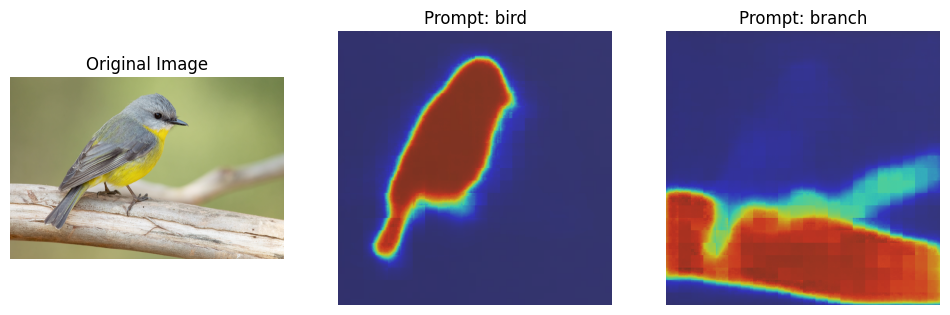

Processing cats_dog.png


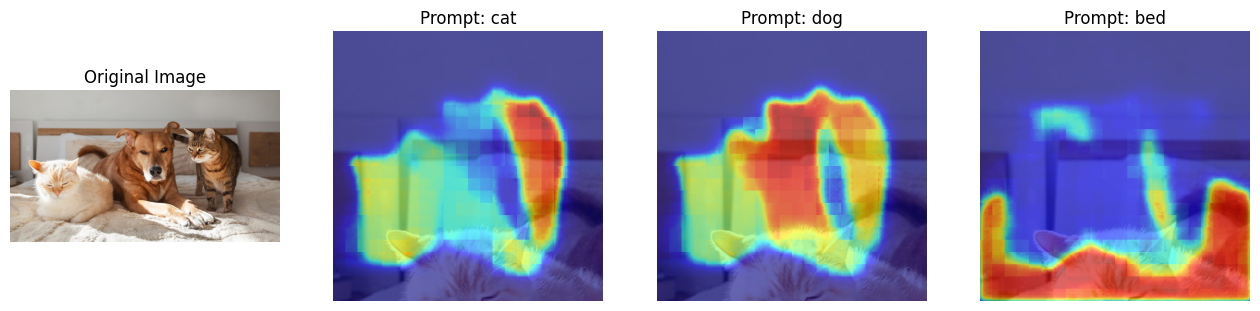

Processing kitchen.png


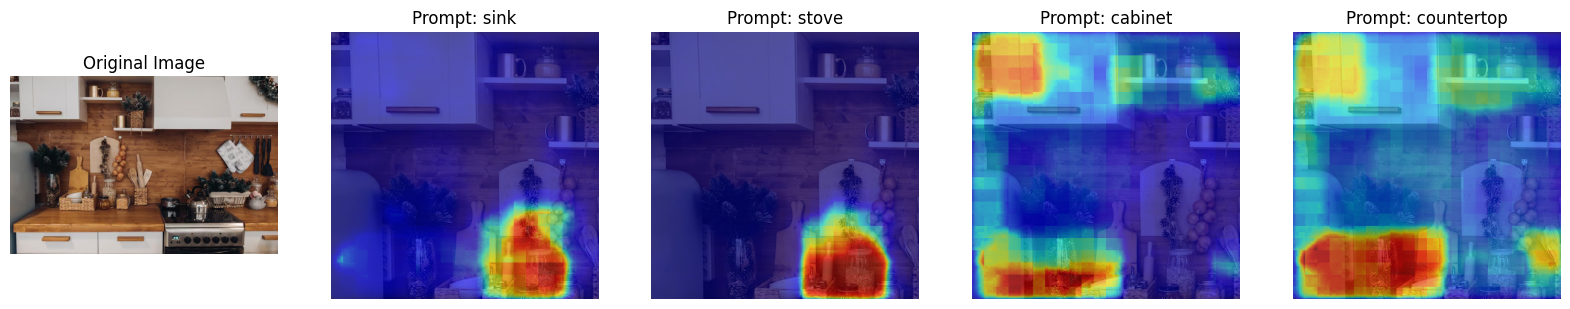

Processing pizza.png


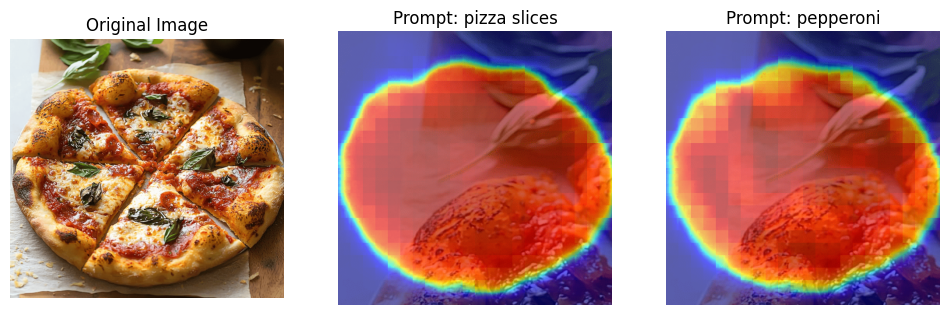

In [6]:
for img_name, prompts in images_and_prompts.items():
    img_path = os.path.join(image_dir, img_name)

    if os.path.exists(img_path):
        print(f"Processing {img_name}")
        image, preds = segment_image(img_path, prompts)
        plot_results(image, preds, prompts)
    else:
        print(f"Image {img_name} not found in {image_dir}")